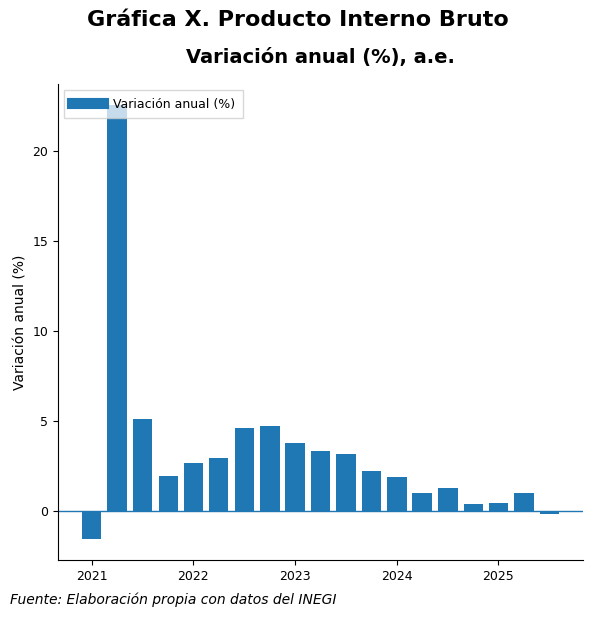

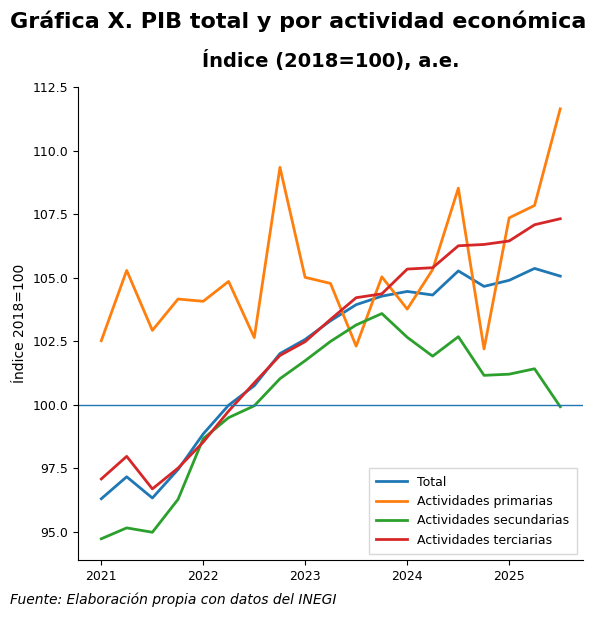

In [32]:
# ============================================================
# INEGI PIB Trimestral (desestacionalizado) - Gráficas tipo INEGI
# Base del índice: 2018 = 100 (promedio de 2018)
# Archivos: pibt_cte_valor.xlsx (niveles, millones de pesos 2018)
#           pibt_cte_var_anual.xlsx (variación % a/a)
# ============================================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# CONFIG
# ----------------------------
PATH_VALOR = "raw/pibt_cte_valor.xlsx"
PATH_VARAA = "raw/pibt_cte_var_anual.xlsx"

SHEET_VALOR = 0   # o "desest-valor"
SHEET_VARAA = 0   # o "desest-var anual"

BASE_YEAR = 2018

# ----------------------------
# HELPERS: parsear INEGI "raro"
# ----------------------------
def _q_to_num(q):
    q = str(q).strip().upper()
    return {"I": 1, "II": 2, "III": 3, "IV": 4}.get(q, np.nan)

def read_inegi_pib_excel(path, sheet=0):
    raw = pd.read_excel(path, sheet_name=sheet, header=None)

    # Buscar la fila donde aparece "Denominación"
    denom_rows = raw.index[raw.iloc[:, 0].astype(str).str.contains(r"Denominación", na=False)]
    if len(denom_rows) == 0:
        raise ValueError("No encontré la fila 'Denominación'. Revisa el archivo/hoja.")
    row_year = int(denom_rows[0])
    row_q = row_year + 1
    row_data0 = row_year + 2

    years = raw.iloc[row_year, :].copy()
    quarters = raw.iloc[row_q, :].copy()

    years_num = pd.to_numeric(years, errors="coerce")
    years_ffill = years_num.ffill()

    qnum = quarters.map(_q_to_num)
    data_cols = raw.columns[(~years_ffill.isna()) & (~qnum.isna())]

    periods = []
    for c in data_cols:
        y = int(years_ffill.loc[c])
        q = int(qnum.loc[c])
        periods.append((c, y, q, pd.Period(f"{y}Q{q}", freq="Q")))

    # ---- datos
    df = raw.iloc[row_data0:, :].copy()
    idx = df.index  # <- IMPORTANTÍSIMO: conservar el índice real del Excel

    colA = df.iloc[:, 0]
    colB = df.iloc[:, 1] if df.shape[1] > 1 else pd.Series(np.nan, index=idx)

    # Algunas filas: A=código, B=nombre. Otras: A=nombre, B=vacío.
    serie = pd.Series(np.where(colB.notna(), colB.astype(str), colA.astype(str)), index=idx).str.strip()
    code  = pd.Series(np.where(colB.notna(), colA, np.nan), index=idx)

    out = pd.DataFrame({"code": code, "serie": serie}, index=idx)

    # Filtrar filas vacías/no-serie
    mask_good = out["serie"].notna() & (out["serie"].str.strip() != "") & (~out["serie"].str.contains(r"^nan$", na=False))
    out = out.loc[mask_good].copy()
    df = df.loc[out.index, :].copy()   # <- ya no truena

    # Melt “manual”
    rows = []
    for (c, y, q, per) in periods:
        vals = pd.to_numeric(df[c], errors="coerce")
        tmp = out.copy()
        tmp["year"] = y
        tmp["quarter"] = q
        tmp["date"] = per.to_timestamp(how="end")
        tmp["value"] = vals.values
        rows.append(tmp)

    long = pd.concat(rows, ignore_index=True)
    long = long.dropna(subset=["value"])
    long = long.sort_values(["serie", "date"]).reset_index(drop=True)
    return long

    """
    Lee el formato de INEGI como el de tus archivos:
    - Fila con 'Denominación' + años en columnas (con huecos) -> row_year
    - Fila siguiente con trimestres I, II, III, IV -> row_q
    - Datos a partir de la siguiente fila
    Maneja que algunas series tienen:
      colA = código, colB = nombre
    y otras:
      colA = nombre, colB = vacío
    Regresa df largo: [code, serie, year, quarter, date, value]
    """
    raw = pd.read_excel(path, sheet_name=sheet, header=None)

    # Buscar la fila donde aparece "Denominación"
    denom_rows = raw.index[raw.iloc[:, 0].astype(str).str.contains(r"Denominación", na=False)]
    if len(denom_rows) == 0:
        raise ValueError("No encontré la fila 'Denominación'. Revisa el archivo/hoja.")
    row_year = int(denom_rows[0])
    row_q = row_year + 1
    row_data0 = row_year + 2

    # Extraer encabezados de años y trimestres (a partir de col 2 o 3; en tus archivos es col 2=vacío, col 3 empieza)
    years = raw.iloc[row_year, :].copy()
    quarters = raw.iloc[row_q, :].copy()

    # Convertir years a numérico donde aplique y forward-fill hacia la derecha
    years_num = pd.to_numeric(years, errors="coerce")
    years_ffill = years_num.ffill()

    # Detectar columnas de datos: donde haya año y trimestre válido
    qnum = quarters.map(_q_to_num)
    data_cols = raw.columns[(~years_ffill.isna()) & (~qnum.isna())]

    # Construir etiquetas de periodo tipo 1994Q1
    periods = []
    for c in data_cols:
        y = int(years_ffill.loc[c])
        q = int(qnum.loc[c])
        periods.append((c, y, q, pd.Period(f"{y}Q{q}", freq="Q")))

    # Datos: columnas A,B + columnas de periodos
    df = raw.iloc[row_data0:, :].copy()

    # Identificar serie y código
    # Si colB no es nan -> colA es código, colB es nombre
    # Si colB es nan -> colA es nombre, código = nan
    colA = df.iloc[:, 0]
    colB = df.iloc[:, 1] if df.shape[1] > 1 else pd.Series([np.nan]*len(df))

    serie = np.where(colB.notna(), colB.astype(str), colA.astype(str))
    code = np.where(colB.notna(), colA, np.nan)

    out = pd.DataFrame({
        "code": code,
        "serie": pd.Series(serie).str.strip()
    })

    # Filtrar filas vacías/no-serie
    out = out[~out["serie"].isna() & (out["serie"].str.strip() != "")]
    df = df.loc[out.index, :].copy()

    # Adjuntar valores por periodo (melt manual)
    rows = []
    for (c, y, q, per) in periods:
        vals = pd.to_numeric(df.loc[out.index, c], errors="coerce")
        tmp = out.copy()
        tmp["year"] = y
        tmp["quarter"] = q
        tmp["date"] = per.to_timestamp(how="end")  # fin de trimestre (puedes cambiar a 'start' si prefieres)
        tmp["value"] = vals.values
        rows.append(tmp)

    long = pd.concat(rows, ignore_index=True)
    long = long.dropna(subset=["value"])
    long = long.sort_values(["serie", "date"]).reset_index(drop=True)
    return long

def make_index_base_year(level_df, serie_name, base_year=2018):
    """
    Crea índice base_year=100 usando el promedio de los 4 trimestres del año base.
    level_df debe tener columnas: ['serie','date','value'].
    """
    s = level_df[level_df["serie"] == serie_name].copy()
    if s.empty:
        raise ValueError(f"No encontré la serie '{serie_name}' en el archivo de niveles.")
    s["year"] = pd.DatetimeIndex(s["date"]).year

    base = s.loc[s["year"] == base_year, "value"].mean()
    if pd.isna(base) or base == 0:
        raise ValueError(f"No pude calcular la base del índice para {base_year}. ¿Hay datos completos de {base_year}?")

    s["index"] = 100.0 * s["value"] / base
    return s[["date", "index"]].sort_values("date")

# ----------------------------
# 1) LEER ARCHIVOS
# ----------------------------
nivel = read_inegi_pib_excel(PATH_VALOR, sheet=SHEET_VALOR)   # millones de pesos a precios 2018
yoy   = read_inegi_pib_excel(PATH_VARAA, sheet=SHEET_VARAA)   # % a/a

# ----------------------------
# 2) ELEGIR SERIES (nombres tal como vienen)
# ----------------------------
SERIE_TOTAL = "Producto interno bruto, a precios de mercado"
SERIE_PRIM  = "Actividades primarias"
SERIE_SEC   = "Actividades secundarias"
SERIE_TER   = "Actividades terciarias"

# ----------------------------
# 3) PREPARAR SERIES PARA GRÁFICAS
# ----------------------------
# Gráfica 13: barras yoy (total) + línea índice (total)
yoy_total = yoy[yoy["serie"] == SERIE_TOTAL][["date", "value"]].rename(columns={"value": "yoy"}).sort_values("date")
idx_total = make_index_base_year(nivel, SERIE_TOTAL, base_year=BASE_YEAR)

# Merge por fecha (si faltan algunos trimestres en una u otra, se alinea con outer)
g13 = pd.merge(yoy_total, idx_total, on="date", how="outer").sort_values("date")

# Gráfica 14: índices para total + 3 actividades
idx_prim = make_index_base_year(nivel, SERIE_PRIM, base_year=BASE_YEAR).rename(columns={"index": "prim"})
idx_sec  = make_index_base_year(nivel, SERIE_SEC,  base_year=BASE_YEAR).rename(columns={"index": "sec"})
idx_ter  = make_index_base_year(nivel, SERIE_TER,  base_year=BASE_YEAR).rename(columns={"index": "ter"})
idx_tot2 = idx_total.rename(columns={"index": "total"})

g14 = idx_tot2.merge(idx_prim, on="date", how="outer") \
             .merge(idx_sec,  on="date", how="outer") \
             .merge(idx_ter,  on="date", how="outer") \
             .sort_values("date")

# ----------------------------
# 4) PLOTEAR (estilo INEGI-ish)
# ----------------------------
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

# ===== Gráfica 13 =====
# filtrar 2018-2025 (incluyente)
g13_plot = g13[(g13["date"] >= "2021-01-01") & (g13["date"] <= "2025-12-31")].copy()

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.bar(g13_plot["date"], g13_plot["yoy"], width=70, align="center")
ax.axhline(0, linewidth=1)

fig.suptitle("Gráfica X. Producto Interno Bruto", fontsize=16, fontweight="bold", y=0.98)
ax.set_title("Variación anual (%), a.e.", fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Variación anual (%)")

d = pd.DatetimeIndex(g13_plot["date"])
mask_q1 = d.quarter == 1

ax.set_xticks(g13_plot.loc[mask_q1, "date"])
ax.set_xticklabels(g13_plot.loc[mask_q1, "date"].dt.year.astype(str), rotation=0)






# leyenda simple
from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0],[0], linewidth=8, label="Variación anual (%)")
]
ax.legend(handles=legend_elems, loc="upper left",
    frameon=True,
    fancybox=False,
    framealpha=.75,
    borderpad=0.6,
    handlelength=2.5,
    handletextpad=0.8,
    columnspacing=1.2)
fig.text(
    0.02, -0.01,
    "Fuente: Elaboración propia con datos del INEGI", fontsize=10, style="italic"
)
plt.tight_layout()
plt.show()

# ===== Gráfica 14 =====
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

# filtrar desde 2021 en adelante
g14_plot = g14[g14["date"] >= "2021-01-01"].copy()

ax.plot(g14_plot["date"], g14_plot["total"], linewidth=2, label="Total")
ax.plot(g14_plot["date"], g14_plot["prim"],  linewidth=2, label="Actividades primarias")
ax.plot(g14_plot["date"], g14_plot["sec"],   linewidth=2, label="Actividades secundarias")
ax.plot(g14_plot["date"], g14_plot["ter"],   linewidth=2, label="Actividades terciarias")

ax.axhline(100, linewidth=1)  # base
fig.suptitle("Gráfica X. PIB total y por actividad económica", fontsize=16, fontweight="bold", y=0.98)
ax.set_title("Índice (2018=100), a.e.", fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel(f"Índice {BASE_YEAR}=100")

# ticks anuales en Q1
d = pd.DatetimeIndex(g14_plot["date"])
mask_q1 = d.quarter == 1

ax.set_xticks(g14_plot.loc[mask_q1, "date"])
ax.set_xticklabels(g14_plot.loc[mask_q1, "date"].dt.year.astype(str), rotation=0)



ax.legend(loc="lower right",
    frameon=True,
    fancybox=False,
    framealpha=.75,
    borderpad=0.6,
    handlelength=2.5,
    handletextpad=0.8,
    columnspacing=1.2)
plt.tight_layout()
fig.text(
    0.02, -0.01,
    "Fuente: Elaboración propia con datos del INEGI", fontsize=10, style="italic"
)
plt.show()

# ----------------------------
# 5) (Opcional) Exportar datos listos para replicar/editar
# ----------------------------
# g13.to_csv("g13_pib_total_yoy_index_base2018.csv", index=False)
# g14.to_csv("g14_pib_indices_actividad_base2018.csv", index=False)


/var/folders/5x/v_n3jdfd003f7mqj3m9j1k0h0000gn/T/ipykernel_32878/3776598650.py:207: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 1])


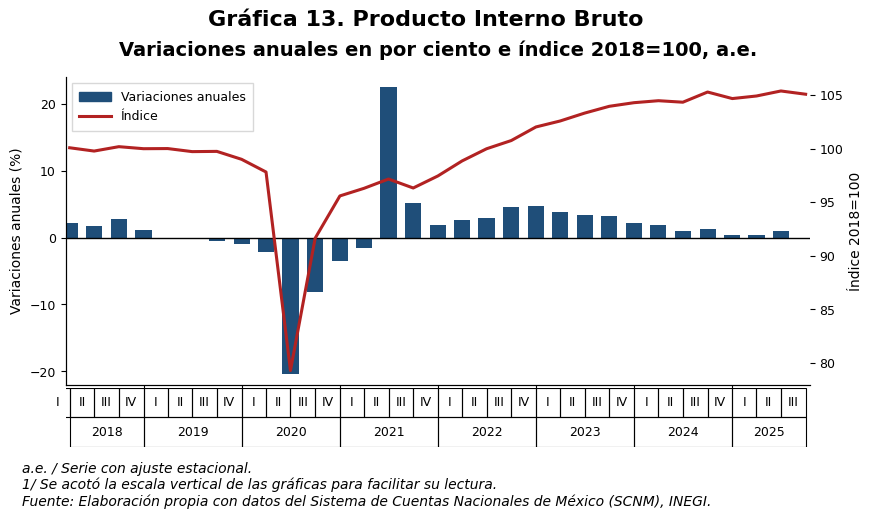

/var/folders/5x/v_n3jdfd003f7mqj3m9j1k0h0000gn/T/ipykernel_32878/3776598650.py:256: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


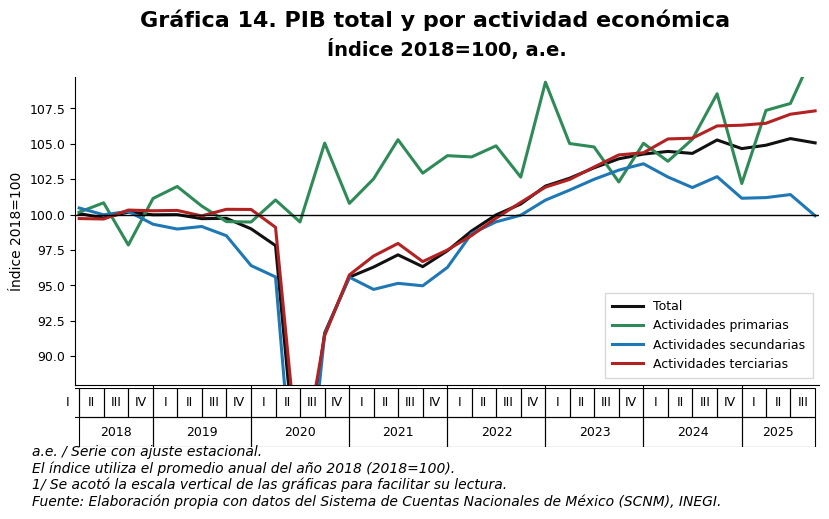

<Figure size 640x480 with 0 Axes>

In [47]:
# ============================
# PLOTEO "INEGI STYLE"
# ============================

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ---- Config visual
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

# ---- Colores (aprox. a la referencia)
C_BARS  = "#1f4e79"   # azul barras
C_LINE  = "#b22222"   # rojo índice
C_TOTAL = "#111111"   # total negro/gris
C_PRIM  = "#2e8b57"   # primarias verde
C_SEC   = "#1f77b4"   # secundarias azul
C_TER   = "#b22222"   # terciarias rojo

# ---- Limitar al periodo de la referencia (2018 en adelante)
START_YEAR = 2018
start_date = pd.Timestamp(f"{START_YEAR}-01-01")

g13p = g13[g13["date"] >= start_date].copy()
g14p = g14[g14["date"] >= start_date].copy()

# ---- Helper para eje x: trimestres + años abajo
ROMAN = {1:"I", 2:"II", 3:"III", 4:"IV"}
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle

ROMAN = {1:"I", 2:"II", 3:"III", 4:"IV"}

def make_inegi_figure(figsize=(9.6, 4.8), box_height=1.6):
    """
    Crea figura con 2 filas:
      - arriba: gráfica
      - abajo: cajitas tipo INEGI
    """
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 1, height_ratios=[10, box_height], hspace=0.02)
    ax = fig.add_subplot(gs[0])
    axbox = fig.add_subplot(gs[1], sharex=ax)
    return fig, ax, axbox

def draw_inegi_boxes(axbox, dates):
    """
    Dibuja las cajitas de trimestres (fila superior) y años (fila inferior).
    `dates` deben ser timestamps trimestrales (como los que ya tienes en g13p/g14p).
    """
    d = pd.to_datetime(pd.Series(dates)).dropna().sort_values().unique()
    if len(d) == 0:
        return

    # Pasar a periodos trimestrales
    per = pd.PeriodIndex(pd.to_datetime(d), freq="Q")

    q_start = per.start_time
    q_end   = per.end_time

    axbox.set_ylim(0, 2)  # 0-1 años, 1-2 trimestres
    axbox.set_yticks([])
    for s in ["top","right","left","bottom"]:
        axbox.spines[s].set_visible(False)

    axbox.tick_params(axis="x", which="both", length=0, labelbottom=False)

    # --- Fila de trimestres (y=1..2)
    for p, x0, x1 in zip(per, q_start, q_end):
        # rectángulo del trimestre
        axbox.add_patch(Rectangle(
            (mdates.date2num(x0), 1),
            mdates.date2num(x1) - mdates.date2num(x0),
            1,
            fill=False, linewidth=0.8, edgecolor="black"
        ))
        # texto I/II/III/IV centrado
        xc = x0 + (x1 - x0)/2
        axbox.text(xc, 1.5, ROMAN[int(p.quarter)], ha="center", va="center", fontsize=9)

    # --- Fila de años (y=0..1): cajota por año
    years = sorted(pd.DatetimeIndex(d).year.unique())
    for yy in years:
        # rango del año recortado al rango disponible
        y0 = pd.Timestamp(f"{yy}-01-01")
        y1 = pd.Timestamp(f"{yy}-12-31 23:59:59")
        # recorta a min/max disponibles
        y0 = max(y0, pd.Timestamp(d[0]))
        y1 = min(y1, pd.Timestamp(d[-1]))

        axbox.add_patch(Rectangle(
            (mdates.date2num(y0), 0),
            mdates.date2num(y1) - mdates.date2num(y0),
            1,
            fill=False, linewidth=0.8, edgecolor="black"
        ))
        axbox.text(y0 + (y1 - y0)/2, 0.5, str(yy), ha="center", va="center", fontsize=9)

    # Ajuste final límites x
    axbox.set_xlim(pd.Timestamp(d[0]) - pd.Timedelta(days=15),
                   pd.Timestamp(d[-1]) + pd.Timedelta(days=15))

def apply_quarter_year_axis(ax, dates):
    """
    Eje x con:
      - Trimestres I II III IV como ticks "de arriba" (en el eje principal)
      - Años como una segunda fila de etiquetas abajo (secondary axis)
    """
    dates = pd.to_datetime(pd.Series(dates)).sort_values()
    q = dates.dt.quarter
    y = dates.dt.year

    # 1) EJE PRINCIPAL: ticks en cada trimestre con etiqueta I/II/III/IV
    ax.set_xticks(dates)
    ax.set_xticklabels([ROMAN[int(x)] for x in q], rotation=0)
    ax.tick_params(axis="x", which="major", pad=2, length=3)

    # 2) SEGUNDA FILA: años centrados (ponemos el año en Q2 para centrar)
    # buscamos el trimestre Q2 de cada año disponible
    year_ticks = []
    year_labels = []
    for yy in sorted(y.unique()):
        mask_q2 = (y == yy) & (q == 2)
        if mask_q2.any():
            year_ticks.append(dates[mask_q2].iloc[0])
            year_labels.append(str(yy))

    ax_year = ax.secondary_xaxis("bottom")
    ax_year.spines["bottom"].set_position(("outward", 18))  # separa la fila de años
    ax_year.set_xticks(year_ticks)
    ax_year.set_xticklabels(year_labels)
    ax_year.tick_params(axis="x", pad=2, length=0)
    ax_year.spines["bottom"].set_visible(False)

    return ax_year

def footnotes(fig, text_left):
    fig.text(0.08, 0.02, text_left, ha="left", va="bottom", fontsize=8)

# ============================
# GRÁFICA 13
# ============================
# ===== Gráfica 13 (INEGI-style con cajitas) =====
fig, ax, axbox = make_inegi_figure(figsize=(9.6, 4.8), box_height=1.9)

# Barras variación anual
ax.bar(g13p["date"], g13p["yoy"], width=60, color=C_BARS, label="Variaciones anuales")
ax.axhline(0, color="black", linewidth=1)
fig.suptitle(
     "Gráfica 13. Producto Interno Bruto",fontsize=16, fontweight="bold", y=1.02
)
ax.set_title(
    f"Variaciones anuales en por ciento e índice {BASE_YEAR}=100, a.e.", 
    fontsize=14, fontweight="bold", pad=15
)
ax.set_ylabel("Variaciones anuales (%)")

# Eje derecho: índice
ax2 = ax.twinx()
ax2.plot(g13p["date"], g13p["index"], color=C_LINE, linewidth=2.2, label="Índice")
ax2.set_ylabel(f"Índice {BASE_YEAR}=100")

# Quitar ticks normales de x en la gráfica (los pone la tablita)
ax.tick_params(axis="x", labelbottom=False)

# Leyenda dentro (como referencia)
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
handles = [
    Patch(facecolor=C_BARS, edgecolor=C_BARS, label="Variaciones anuales"),
    Line2D([0],[0], color=C_LINE, linewidth=2.2, label="Índice"),
]
ax.legend(handles=handles, loc="upper left",
    frameon=True,
    fancybox=False,
    framealpha=.75,
    borderpad=0.6,
    handlelength=2.5,
    handletextpad=0.8,
    columnspacing=1.2)

# Acotar y (como INEGI)
ymin = np.nanmin(g13p["yoy"])
ymax = np.nanmax(g13p["yoy"])
ax.set_ylim(min(-12, ymin - 1.5), max(10, ymax + 1.5))

# Dibujar cajitas
draw_inegi_boxes(axbox, g13p["date"])

# Footnotes
fig.text(
    0.08, -0.02,
    "a.e. / Serie con ajuste estacional.\n"
    "1/ Se acotó la escala vertical de las gráficas para facilitar su lectura.\n"
    "Fuente: Elaboración propia con datos del Sistema de Cuentas Nacionales de México (SCNM), INEGI.",
    ha="left", va="bottom", fontsize=10, style="italic"
)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

# ===== Gráfica 14 (INEGI-style con cajitas) =====
fig, ax, axbox = make_inegi_figure(figsize=(9.6, 4.8), box_height=1.9)

ax.plot(g14p["date"], g14p["total"], color=C_TOTAL, linewidth=2.2, label="Total")
ax.plot(g14p["date"], g14p["prim"],  color=C_PRIM,  linewidth=2.2, label="Actividades primarias")
ax.plot(g14p["date"], g14p["sec"],   color=C_SEC,   linewidth=2.2, label="Actividades secundarias")
ax.plot(g14p["date"], g14p["ter"],   color=C_TER,   linewidth=2.2, label="Actividades terciarias")

ax.axhline(100, color="black", linewidth=1)
fig.suptitle(
    "Gráfica 14. PIB total y por actividad económica",fontsize=16, fontweight="bold", y=1.02
)
ax.set_title(
    f"Índice {BASE_YEAR}=100, a.e.", fontsize=14, fontweight="bold", pad=15
)
ax.set_ylabel(f"Índice {BASE_YEAR}=100")
ax.tick_params(axis="x", labelbottom=False)

# Leyenda dentro abajo derecha
ax.legend(loc="lower right",
    frameon=True,
    fancybox=False,
    framealpha=.75,
    borderpad=0.6,
    handlelength=2.5,
    handletextpad=0.8,
    columnspacing=1.2)

# Acotar y (INEGI-ish)
low = np.nanpercentile(g14p[["total","prim","sec","ter"]].values, 2)
high = np.nanpercentile(g14p[["total","prim","sec","ter"]].values, 98)
ax.set_ylim(max(88, low - 1.5), min(112, high + 1.5))

# Cajitas
draw_inegi_boxes(axbox, g14p["date"])

# Footnotes
fig.text(
    0.08, -0.02,
    "a.e. / Serie con ajuste estacional.\n"
    f"El índice utiliza el promedio anual del año {BASE_YEAR} ({BASE_YEAR}=100).\n"
    "1/ Se acotó la escala vertical de las gráficas para facilitar su lectura.\n"
    "Fuente: Elaboración propia con datos del Sistema de Cuentas Nacionales de México (SCNM), INEGI.",
    ha="left", va="bottom", fontsize=10, style="italic"
)

plt.tight_layout()
plt.show()

# Footnotes (misma idea que referencia; si quieres, luego le metemos participaciones entre paréntesis)
fig.text(
    0.08, -0.02,
    "a.e. / Serie con ajuste estacional.\n"
    f"El índice utiliza el promedio anual del año {BASE_YEAR} ({BASE_YEAR}=100).\n"
    "1/ Se acotó la escala vertical de las gráficas para facilitar su lectura.\n"
    "Fuente: Elaboración propia con datos del Sistema de Cuentas Nacionales de México (SCNM), INEGI.", 
    fontsize=10, style="italic"

)

plt.tight_layout()
plt.show()


Series elegidas:
Total      : Indicador Global de la Actividad Económica
Primarias  : Actividades primarias
Secundarias: Actividades secundarias
Terciarias : Actividades terciarias


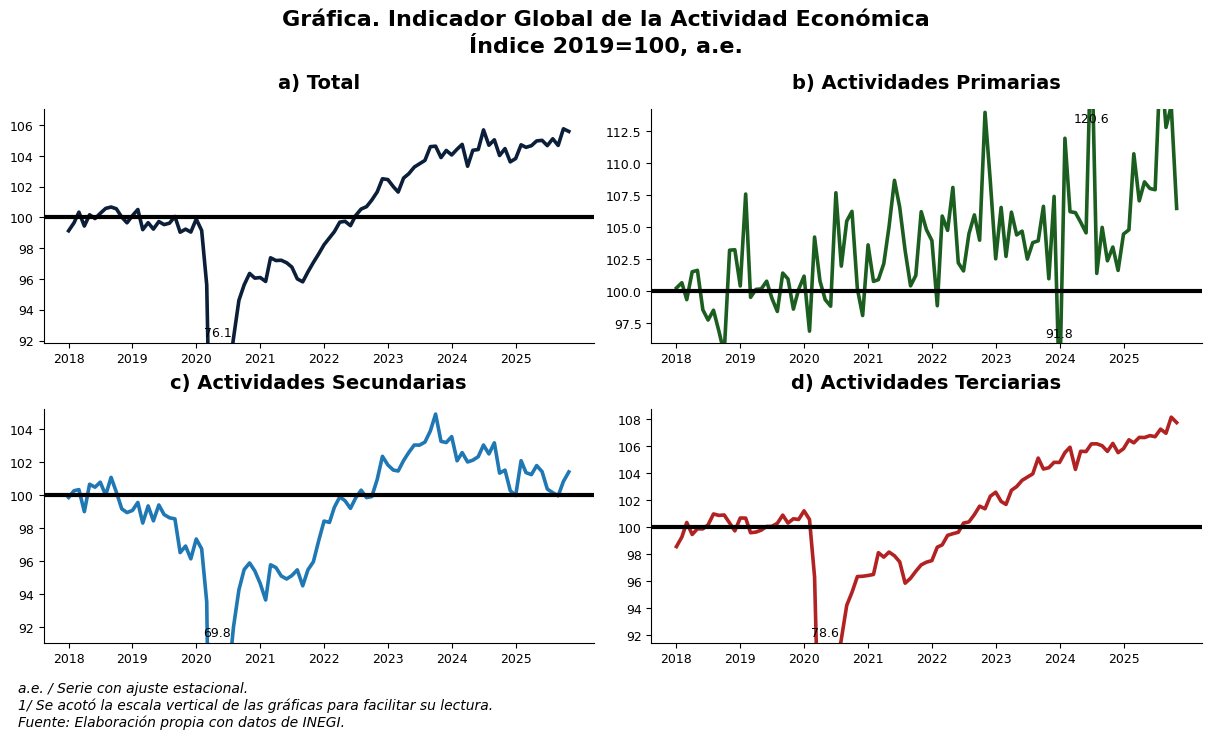

In [51]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.transforms import blended_transform_factory

PATH_IGAE = "raw/igae_indice.xlsx"
SHEET_IGAE = 0  # si tu hoja tiene nombre, ponlo aquí

# ============================================================
# 1) Lectura robusta (formato INEGI raro: años arriba, meses abajo)
# ============================================================

MONTH_MAP = {
    "ENE": 1, "FEB": 2, "MAR": 3, "ABR": 4, "MAY": 5, "JUN": 6,
    "JUL": 7, "AGO": 8, "SEP": 9, "OCT": 10, "NOV": 11, "DIC": 12,
    "JAN": 1, "FEBR": 2, "APR": 4, "AUG": 8, "DEC": 12,  # por si viene mezclado
}

def _m_to_num(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().upper()
    s = re.sub(r"[^\w]", "", s)
    # acepta "Ene", "ENERO", "01", etc.
    if s.isdigit():
        m = int(s)
        return m if 1 <= m <= 12 else np.nan
    s3 = s[:3]
    return MONTH_MAP.get(s3, np.nan)

def read_inegi_wide_time_excel(path, sheet=0):
    """
    Devuelve df largo: [serie, date, value].
    Maneja:
    - fila "Denominación" con años (ffill)
    - fila siguiente con meses (Ene..Dic) o números 1..12
    - col A/col B pueden ser código/nombre
    """
    raw = pd.read_excel(path, sheet_name=sheet, header=None)

    # Caso A: formato con "Denominación"
    denom_rows = raw.index[raw.iloc[:, 0].astype(str).str.contains(r"Denominación", na=False)]
    if len(denom_rows) > 0:
        row_year = int(denom_rows[0])
        row_m = row_year + 1
        row_data0 = row_year + 2

        years = pd.to_numeric(raw.iloc[row_year, :], errors="coerce").ffill()
        months = raw.iloc[row_m, :].map(_m_to_num)

        data_cols = raw.columns[(~years.isna()) & (~months.isna())]

        periods = []
        for c in data_cols:
            y = int(years.loc[c])
            m = int(months.loc[c])
            dt = pd.Timestamp(year=y, month=m, day=1)
            periods.append((c, dt))

        df = raw.iloc[row_data0:, :].copy()
        idx = df.index

        colA = df.iloc[:, 0]
        colB = df.iloc[:, 1] if df.shape[1] > 1 else pd.Series(np.nan, index=idx)

        serie = pd.Series(np.where(colB.notna(), colB.astype(str), colA.astype(str)), index=idx).str.strip()
        out = pd.DataFrame({"serie": serie}, index=idx)
        mask_good = out["serie"].notna() & (out["serie"].str.strip() != "") & (~out["serie"].str.contains(r"^nan$", na=False))
        out = out.loc[mask_good].copy()
        df = df.loc[out.index, :].copy()

        rows = []
        for c, dt in periods:
            vals = pd.to_numeric(df[c], errors="coerce")
            tmp = out.copy()
            tmp["date"] = dt
            tmp["value"] = vals.values
            rows.append(tmp)

        long = pd.concat(rows, ignore_index=True).dropna(subset=["value"])
        long = long.sort_values(["serie", "date"]).reset_index(drop=True)
        return long

    # Caso B: si NO hay "Denominación", intenta detectar una columna fecha
    # (por ejemplo una col con fechas y columnas de series)
    tmp = pd.read_excel(path, sheet_name=sheet)
    date_col = None
    for c in tmp.columns:
        if pd.api.types.is_datetime64_any_dtype(tmp[c]):
            date_col = c
            break
    if date_col is None:
        # intenta parsear primera columna como fecha
        cand = pd.to_datetime(tmp.iloc[:, 0], errors="coerce")
        if cand.notna().mean() > 0.8:
            tmp = tmp.copy()
            tmp["__date__"] = cand
            date_col = "__date__"

    if date_col is None:
        raise ValueError("No pude inferir el formato del Excel. Comparte una captura de las primeras filas/columnas.")

    long = tmp.melt(id_vars=[date_col], var_name="serie", value_name="value")
    long = long.rename(columns={date_col: "date"})
    long["date"] = pd.to_datetime(long["date"])
    long["value"] = pd.to_numeric(long["value"], errors="coerce")
    long = long.dropna(subset=["date", "value"]).sort_values(["serie", "date"]).reset_index(drop=True)
    return long

igae = read_inegi_wide_time_excel(PATH_IGAE, sheet=SHEET_IGAE)

# ============================================================
# 2) Selección automática de series (por texto)
# ============================================================

def pick_series(df, include_keywords, exclude_regex=None):
    """
    Escoge un nombre de serie en df['serie'] usando keywords (case-insensitive),
    y opcionalmente excluye nombres que matcheen un regex (ej. subsectores con número).
    """
    names = pd.Series(df["serie"].astype(str).unique()).dropna()
    names = names[names.str.strip() != ""]

    if exclude_regex is not None:
        names = names[~names.str.contains(exclude_regex, case=False, na=False)]

    score = pd.Series(0, index=names.index, dtype=int)
    for kw in include_keywords:
        score += names.str.contains(kw, case=False, na=False).astype(int)

    best_i = score.idxmax()
    if score.loc[best_i] == 0:
        raise ValueError(
            "No pude identificar la serie. Imprime:\n"
            "sorted(igae['serie'].unique())[:80]\n"
            "y ajustamos keywords."
        )
    return names.loc[best_i]

# Excluir subsectores tipo "21 Minería", "31-33 Industrias manufactureras", etc.
EXCL = r"^\s*\d"

SER_TOTAL = pick_series(igae, ["Indicador Global", "Actividad Económica"], exclude_regex=EXCL)
SER_PRIM  = pick_series(igae, ["Actividades primarias"], exclude_regex=EXCL)
SER_SEC   = pick_series(igae, ["Actividades secundarias"], exclude_regex=EXCL)
SER_TER   = pick_series(igae, ["Actividades terciarias"], exclude_regex=EXCL)

print("Series elegidas:")
print("Total      :", SER_TOTAL)
print("Primarias  :", SER_PRIM)
print("Secundarias:", SER_SEC)
print("Terciarias :", SER_TER)




def get_ts(df, serie_name):
    s = df[df["serie"] == serie_name][["date","value"]].dropna().sort_values("date")
    return s

ts_total = get_ts(igae, SER_TOTAL)
ts_prim  = get_ts(igae, SER_PRIM)
ts_sec   = get_ts(igae, SER_SEC)
ts_ter   = get_ts(igae, SER_TER)

# Limitar a 2018+
START = pd.Timestamp("2018-01-01")
ts_total = ts_total[ts_total["date"] >= START]
ts_prim  = ts_prim[ts_prim["date"]  >= START]
ts_sec   = ts_sec[ts_sec["date"]   >= START]
ts_ter   = ts_ter[ts_ter["date"]   >= START]

# ============================================================
# 3) Plot estilo referencia, con "break" si el rango se sale
# ============================================================

# Colores como referencia (aprox)
C_TOTAL = "#0b1f3a"   # azul muy oscuro
C_PRIM  = "#1b5e20"   # verde
C_SEC   = "#1f77b4"   # azul
C_TER   = "#b22222"   # rojo

plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

def nice_ylim(values, target_center=100, pad=2.0):
    """
    y-lims parecidos a la referencia: usa percentiles para evitar outliers,
    pero garantiza que 100 esté dentro.
    """
    v = np.asarray(values, dtype=float)
    v = v[~np.isnan(v)]
    lo = np.percentile(v, 5)
    hi = np.percentile(v, 95)
    lo = min(lo, target_center) - pad
    hi = max(hi, target_center) + pad
    return lo, hi

#def add_axis_break(ax, where="bottom"):
    """
    Dibuja las dos rayitas '//' como en la referencia (en coordenadas del eje).
    """
    trans = blended_transform_factory(ax.transAxes, ax.transAxes)
    x0 = 0.45
    dx = 0.02
    if where == "bottom":
        y = 0.02
    else:
        y = 0.98
    for shift in [-0.02, +0.02]:
        ax.plot([x0+shift, x0+shift+dx], [y, y], transform=trans, color="black", lw=2, clip_on=False)

def plot_panel(ax, ts, color, panel_title, show_break=True):
    ax.plot(ts["date"], ts["value"], color=color, lw=2.6)
    ax.axhline(100, color="black", lw=3)  # base gruesa

    # X ticks por año como en referencia
    years = pd.date_range(ts["date"].min(), ts["date"].max(), freq="YS")
    ax.set_xticks(years)
    ax.set_xticklabels([d.year for d in years])

    # Y-lims "bonitos"
    lo, hi = nice_ylim(ts["value"].values, pad=2.0)
    ax.set_ylim(lo, hi)

    ax.set_title(panel_title, fontsize=14, fontweight="bold", pad=15)

    # Break + anotación si el mínimo/máximo se sale del rango visible
    if show_break:
        vmin = ts["value"].min()
        vmax = ts["value"].max()

        if vmin < lo:
            #add_axis_break(ax, "bottom")
            # anota el mínimo real
            dmin = ts.loc[ts["value"].idxmin(), "date"]
            ax.text(dmin, lo + 0.2, f"{vmin:.1f}", ha="center", va="bottom", fontsize=9)

        if vmax > hi:
            #add_axis_break(ax, "top")
            dmax = ts.loc[ts["value"].idxmax(), "date"]
            ax.text(dmax, hi - 0.2, f"{vmax:.1f}", ha="center", va="top", fontsize=9)

    # rejilla off (como la referencia)
    ax.grid(False)

# Figura 2x2
fig, axs = plt.subplots(2, 2, figsize=(12, 6), constrained_layout=True)

fig.suptitle("Gráfica. Indicador Global de la Actividad Económica\nÍndice 2019=100, a.e.", fontsize=16, fontweight="bold", y=1.1)

plot_panel(axs[0,0], ts_total, C_TOTAL, "a) Total")
plot_panel(axs[0,1], ts_prim,  C_PRIM,  "b) Actividades Primarias")
plot_panel(axs[1,0], ts_sec,   C_SEC,   "c) Actividades Secundarias")
plot_panel(axs[1,1], ts_ter,   C_TER,   "d) Actividades Terciarias")

# Notas al pie (estilo INEGI/Banxico)
fig.text(
    0.01, -0.02,
    "a.e. / Serie con ajuste estacional.\n"
    "1/ Se acotó la escala vertical de las gráficas para facilitar su lectura.\n"
    "Fuente: Elaboración propia con datos de INEGI.",
    ha="left", va="top", fontsize=10, style="italic"
)

plt.show()


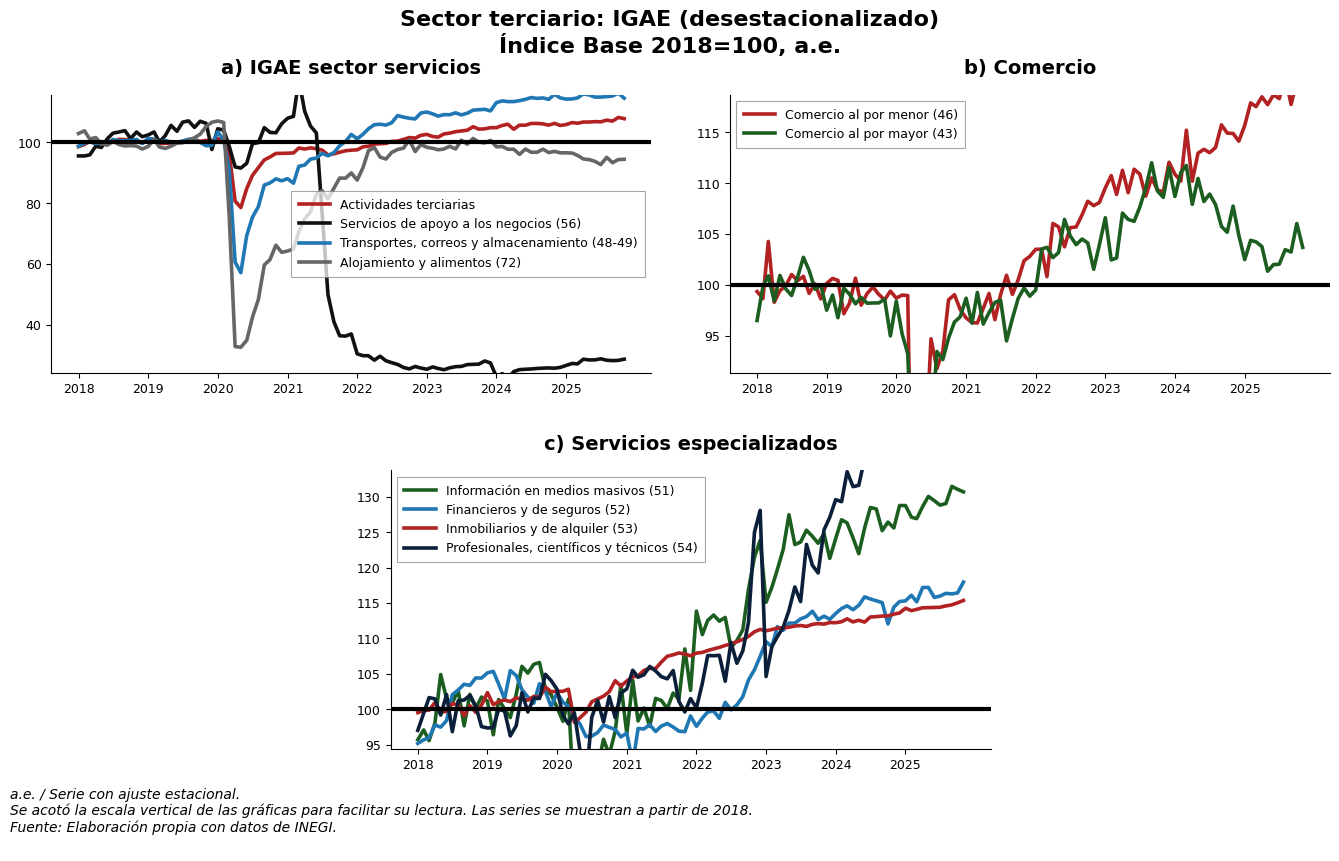

In [18]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.transforms import blended_transform_factory

PATH_IGAE = "raw/igae_indice.xlsx"
SHEET_IGAE = 0

# ============================================================
# 1) LECTOR robusto (Denominación + años + meses)
# ============================================================
MONTH_MAP = {"ENE":1,"FEB":2,"MAR":3,"ABR":4,"MAY":5,"JUN":6,"JUL":7,"AGO":8,"SEP":9,"OCT":10,"NOV":11,"DIC":12}

def _m_to_num(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().upper()
    s = re.sub(r"[^\w]", "", s)
    if s.isdigit():
        m = int(s)
        return m if 1 <= m <= 12 else np.nan
    return MONTH_MAP.get(s[:3], np.nan)

def read_inegi_monthly_excel(path, sheet=0):
    raw = pd.read_excel(path, sheet_name=sheet, header=None)

    denom_rows = raw.index[raw.iloc[:, 0].astype(str).str.contains(r"Denominación", na=False)]
    if len(denom_rows) == 0:
        raise ValueError("No encontré la fila 'Denominación'. Revisa el archivo/hoja.")
    row_year = int(denom_rows[0])
    row_m = row_year + 1
    row_data0 = row_year + 2

    years = pd.to_numeric(raw.iloc[row_year, :], errors="coerce").ffill()
    months = raw.iloc[row_m, :].map(_m_to_num)

    data_cols = raw.columns[(~years.isna()) & (~months.isna())]

    periods = []
    for c in data_cols:
        y = int(years.loc[c])
        m = int(months.loc[c])
        dt = pd.Timestamp(year=y, month=m, day=1)
        periods.append((c, dt))

    df = raw.iloc[row_data0:, :].copy()
    idx = df.index

    colA = df.iloc[:, 0]
    colB = df.iloc[:, 1] if df.shape[1] > 1 else pd.Series(np.nan, index=idx)

    # Si B tiene texto, B es la denominación (subsectores vienen ahí)
    serie = pd.Series(np.where(colB.notna(), colB.astype(str), colA.astype(str)), index=idx).str.strip()

    out = pd.DataFrame({"serie": serie}, index=idx)
    mask_good = out["serie"].notna() & (out["serie"].str.strip() != "") & (~out["serie"].str.contains(r"^nan$", na=False))
    out = out.loc[mask_good].copy()
    df = df.loc[out.index, :].copy()

    rows = []
    for c, dt in periods:
        vals = pd.to_numeric(df[c], errors="coerce")
        tmp = out.copy()
        tmp["date"] = dt
        tmp["value"] = vals.values
        rows.append(tmp)

    long = pd.concat(rows, ignore_index=True).dropna(subset=["value"])
    long = long.sort_values(["serie", "date"]).reset_index(drop=True)
    return long

igae = read_inegi_monthly_excel(PATH_IGAE, sheet=SHEET_IGAE)

# ============================================================
# 2) Series exactas del archivo
# ============================================================
SER_TERC = "Actividades terciarias"
SER_56   = "56 Servicios de apoyo a los negocios y manejo de residuos y desechos, y servicios de remediación"

SER_43 = "43 Comercio al por mayor"
SER_46 = "46 Comercio al por menor"

SER_51 = "51 Información en medios masivos"
SER_52 = "52 Servicios financieros y de seguros"
SER_53 = "53 Servicios inmobiliarios y de alquiler de bienes muebles e intangibles"
SER_54 = "54 Servicios profesionales, científicos y técnicos"

# Extras útiles para política monetaria (opcionales)
SER_4849 = "48-49 Transportes, correos y almacenamiento"
SER_72   = "72 Servicios de alojamiento temporal y de preparación de alimentos y bebidas"

def ts(name):
    s = igae[igae["serie"] == name][["date", "value"]].dropna().sort_values("date").copy()
    s["date"] = pd.to_datetime(s["date"])
    return s

# series base
ter = ts(SER_TERC)
s56 = ts(SER_56)
com_may = ts(SER_43)
com_men = ts(SER_46)
m51 = ts(SER_51)
m52 = ts(SER_52)
m53 = ts(SER_53)
m54 = ts(SER_54)

# extras (si existen en archivo)
extra_transport = ts(SER_4849) if SER_4849 in set(igae["serie"]) else None
extra_aloj      = ts(SER_72)   if SER_72   in set(igae["serie"]) else None

# construir "Servicios excluyendo 56" (aprox): terciario - (56) NO es válido en índice directamente.
# OJO: en la referencia esa línea negra suele ser un índice calculado aparte (no resta simple).
# Con este archivo NO existe una serie ya calculada "terciario excl 56".
# Para replicar la referencia, lo correcto es armar un índice agregado ponderado con pesos SCIAN.
# Mientras no tengamos ponderaciones, te dejo una alternativa práctica:
# (1) si tu Excel incluye una serie explícita "excluyendo servicios de apoyo..." úsala
# (2) si no, omitimos esa línea o la dejamos como "terciario" y "56" para ver el efecto.
#
# ---> Aquí implemento (2) por defecto: rojo=terciario, negro=56 (para decisión de política sirve MUCHO).
USE_BLACK_AS_56 = True

# ============================================================
# 3) Formato tipo referencia + break si se sale del rango
# ============================================================
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

C_RED   = "#b22222"
C_BLACK = "#111111"
C_GREEN = "#1b5e20"
C_BLUE  = "#1f77b4"
C_NAVY  = "#0b1f3a"
C_GRAY  = "#666666"

def nice_ylim(v, center=100, pad=2.0):
    v = np.asarray(v, dtype=float)
    v = v[~np.isnan(v)]
    lo = np.percentile(v, 5)
    hi = np.percentile(v, 95)
    lo = min(lo, center) - pad
    hi = max(hi, center) + pad
    return lo, hi

#def add_axis_break(ax, where="bottom"):

    trans = blended_transform_factory(ax.transAxes, ax.transAxes)
    x0 = 0.48
    dx = 0.03
    y = 0.02 if where == "bottom" else 0.98
    for shift in [-0.03, 0.03]:
        ax.plot([x0+shift, x0+shift+dx], [y, y], transform=trans, color="black", lw=2, clip_on=False)

def panel(ax, series, colors, labels, title=None, ylims=None, annotate_min=True,
          legend_loc="upper left", legend_anchor=None, legend_ncol=2):
    for s, c, lab in zip(series, colors, labels):
        ax.plot(s["date"], s["value"], lw=2.6, color=c, label=lab)

    ax.axhline(100, color="black", lw=3)

    start = min(s["date"].min() for s in series)
    end   = max(s["date"].max() for s in series)
    years = pd.date_range(start.normalize(), end.normalize(), freq="YS")
    ax.set_xticks(years)
    ax.set_xticklabels([d.year for d in years])

    allv = np.concatenate([s["value"].to_numpy() for s in series])
    lo, hi = nice_ylim(allv, pad=2.0)
    if ylims is not None:
        lo, hi = ylims
    ax.set_ylim(lo, hi)

    # Solo pone título si se lo pasas
    if title:
        ax.set_title(title, loc="left", fontweight="bold")

    ax.grid(False)

    leg_kwargs = dict(
        loc=legend_loc,
        frameon=True, fancybox=False, framealpha=.75,
        borderpad=0.6, handlelength=2.5, handletextpad=0.8,
        columnspacing=1.2, ncol=legend_ncol
    )
    if legend_anchor is not None:
        leg_kwargs["bbox_to_anchor"] = legend_anchor

    leg = ax.legend(**leg_kwargs)
    leg.get_frame().set_edgecolor("#888888")
    leg.get_frame().set_linewidth(0.8)

# ============================================================
# CORTAR TODAS LAS SERIES DESDE 2018
# ============================================================
# ============================================================
# Definir series del panel a)
# ============================================================
# Filtrar panel a desde 2018
START = pd.Timestamp("2018-01-01")

def cut2018(s):
    return s[s["date"] >= START].copy()

# series base de panel a
ter = cut2018(ter)
s56 = cut2018(s56)

# opcionales de panel a
if extra_transport is not None:
    extra_transport = cut2018(extra_transport)

if extra_aloj is not None:
    extra_aloj = cut2018(extra_aloj)

# reconstruir listas del panel a ya filtradas
series_a = [ter, s56]
colors_a = [C_RED, C_BLACK]
labels_a = ["Actividades terciarias", "Servicios de apoyo a los negocios (56)"]

if extra_transport is not None:
    series_a.append(extra_transport)
    colors_a.append(C_BLUE)
    labels_a.append("Transportes, correos y almacenamiento (48-49)")

if extra_aloj is not None:
    series_a.append(extra_aloj)
    colors_a.append(C_GRAY)
    labels_a.append("Alojamiento y alimentos (72)")


# panel b)
com_men = cut2018(com_men)
com_may = cut2018(com_may)

# panel c)
m51 = cut2018(m51)
m52 = cut2018(m52)
m53 = cut2018(m53)
m54 = cut2018(m54)




# ============================================================
# FIGURA: 2 arriba + 1 centrado abajo
# ============================================================
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(16.5, 8.5))
gs = gridspec.GridSpec(
    2, 4,
    height_ratios=[1, 1],
    width_ratios=[1, 1, 1, 1],
    hspace=0.35,
    wspace=0.30
)

ax_a = fig.add_subplot(gs[0, 0:2])
ax_a.set_title("a) IGAE sector servicios", fontsize=14, fontweight="bold", pad=15)

ax_b = fig.add_subplot(gs[0, 2:4])
ax_b.set_title("b) Comercio", fontsize=14, fontweight="bold", pad=15)

ax_c = fig.add_subplot(gs[1, 1:3])
ax_c.set_title("c) Servicios especializados", fontsize=14, fontweight="bold", pad=15)

# Quita este bloque (no sirve antes de graficar):
# ax_c.legend(...)

fig.suptitle(
    "Sector terciario: IGAE (desestacionalizado)\nÍndice Base 2018=100, a.e.",
    fontsize=16, fontweight="bold", y=0.98
)

# a) Servicios -> center right
panel(
    ax_a,
    series_a,
    colors_a,
    labels_a,
    legend_loc="center right",
    legend_anchor=None,
    legend_ncol=1
)

# b) Comercio -> upper left
panel(
    ax_b,
    [com_men, com_may],
    [C_RED, C_GREEN],
    ["Comercio al por menor (46)", "Comercio al por mayor (43)"],
    legend_loc="upper left",
    legend_anchor=None,
    legend_ncol=1
)

# c) Servicios especializados -> upper left
panel(
    ax_c,
    [m51, m52, m53, m54],
    [C_GREEN, C_BLUE, C_RED, C_NAVY],
    ["Información en medios masivos (51)",
     "Financieros y de seguros (52)",
     "Inmobiliarios y de alquiler (53)",
     "Profesionales, científicos y técnicos (54)"],
    legend_loc="upper left",
    legend_anchor=None,
    legend_ncol=1
)

fig.text(
    0.1, -0.01,
    "a.e. / Serie con ajuste estacional.\n"
    "Se acotó la escala vertical de las gráficas para facilitar su lectura. Las series se muestran a partir de 2018. \n"
    "Fuente: Elaboración propia con datos de INEGI.\n ",
    ha="left", va="bottom", fontsize=10, style="italic"
)

plt.show()
